In [1]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
import warnings
import matplotlib.pyplot as plt
# import sys
# sys.path.append('/home/robbie/custom_modules/')
from ll_xy import lonlat_to_xy
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [2]:
directory = '/home/robbie/Dropbox/kuka_slush/data/kuka/20231003'

freqs=['ku','ka']
listfiles = os.listdir(directory)
files = {'ku':sorted([f for f in listfiles if f'Ku-Scat' in f]),
         'ka':sorted([f for f in listfiles if f'Ka-Scat' in f])}

files

{'ku': ['kuka_stare_decon_Ku-Scat20231003-103408.nc',
  'kuka_stare_decon_Ku-Scat20231003-103908.nc',
  'kuka_stare_decon_Ku-Scat20231003-132908.nc',
  'kuka_stare_decon_Ku-Scat20231003-133409.nc'],
 'ka': ['kuka_stare_decon_Ka-Scat20231003-103603.nc',
  'kuka_stare_decon_Ka-Scat20231003-104103.nc',
  'kuka_stare_decon_Ka-Scat20231003-133103.nc',
  'kuka_stare_decon_Ka-Scat20231003-133603.nc']}

In [3]:
d = Dataset(f'{directory}/kuka_stare_decon_Ku-Scat20231003-133409.nc')

In [4]:
files['ku'] =  ['kuka_stare_decon_Ku-Scat20231003-103408.nc',
                'kuka_stare_decon_Ku-Scat20231003-103908.nc',
               ]

files['ka'] = ['kuka_stare_decon_Ka-Scat20231003-103603.nc',
                'kuka_stare_decon_Ka-Scat20231003-104103.nc',
              ]


kuka_stare_decon_Ku-Scat20231003-103408.nc 646
kuka_stare_decon_Ku-Scat20231003-103908.nc 646
kuka_stare_decon_Ka-Scat20231003-103603.nc 1158
kuka_stare_decon_Ka-Scat20231003-104103.nc 1158


Text(0, 0.5, 'y distance (m)')

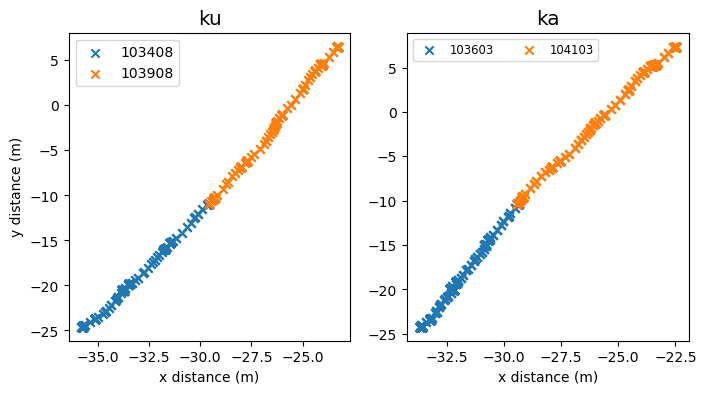

In [5]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

xy_dict = {}

for freq, ax in zip(freqs,[ax1,ax2]):
    
    ax.set_title(freq,fontsize='x-large')
    
    x,y=kt.plot_pos(files['ku'][0],directory,plot=False)
    

    x0 = -2300414.994491106; y0 = 923485.871699531

    xy_dict[freq]={}
    
    for f in files[freq]:

        x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,ax=ax)
        
        print(f,len(x))

        xy_dict[freq][f] = (x,y)

ax1.legend()
ax2.legend(ncol=2,fontsize='small')
ax1.set_xlabel('x distance (m)')
ax2.set_xlabel('x distance (m)')
ax1.set_ylabel('y distance (m)')

In [6]:
# for freq in freqs:  
#     for f in files[freq]:
#         kt.plot_file(f,freq.lower(),directory,
#                          vlines=[])

In [7]:
nearfardict = {}

for freq in ['ku','ka']:
    
    file = files[freq][0]
    d = Dataset(f'{directory}/{file}')
    near=kt.get_range_index(1.3,d['range'])
    far=kt.get_range_index(3,d['range'])
    nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}

/tmp/ipykernel_79196/4284082774.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}


# Combine Files

In [14]:
with warnings.catch_warnings():
    
    warnings.simplefilter('ignore')
    
    data = {}
    
    for freq in ['ku','ka']:
    
        nrcs_list = []
        for foi in files[freq][0:2]:
    
            x,y=xy_dict[freq][foi]
    
            d = Dataset(f'{directory}/{foi}')
    
            time_offset_s=0
            times = np.array([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(x))+datetime.timedelta(seconds=int(time_offset_s)) for x in d['start_time']])
    
            mintime=0
            maxtime=100000
    
            nrcs = pd.DataFrame(kt.get_nrcs(d,freq.lower()))
    
            x_ = 0; y_ = 0
    
            along_track = np.sqrt((x-x_)**2 + (y-y_)**2)
            xdiff = np.diff(x)
            ydiff = np.diff(y)
            speed = np.sqrt(np.square(xdiff)+np.square(ydiff))
            speed=list(speed)+[0]
            nrcs['speed']=speed
            nrcs['along_track']=along_track
            nrcs['time']=np.array(d['start_time']).copy()
            nrcs['x']=x
            nrcs['y']=y
            nrcs['xtilt']=np.array(d['cross_tilt'])
            nrcs['atilt']=np.array(d['along_tilt'])
            nrcs = nrcs.iloc[mintime:maxtime]
    
            vv= np.array(d['vv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                               mintime:maxtime]
            
            hv= np.array(d['hv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                               mintime:maxtime]
            
            nrcs['vv'] = [vv[:,i] for i in range(vv.shape[1])]
            nrcs['hv'] = [hv[:,i] for i in range(hv.shape[1])]
            
            nrcs['code']=[str(i)+foi for i in nrcs.index]
    
            nrcs = nrcs[nrcs['corr']<0.99]
    
            nrcs_list.append( nrcs )
            
    
        data[freq] = pd.concat(nrcs_list)

pickle.dump(data,open('20206_10_03_wfms','wb'))

In [13]:
df

,vv,hv,vh,hh,corr,speed,along_track,time,x,y,xtilt,atilt,code
371,"[2.9043453388911584e-08, 1.129163784746536e-08...",0.004893,0.005530,1.411387,0.966154,0.004468,0.061507,1.696329e+09,-33.630323,-24.199243,-0.925337,-1.186536,371kuka_stare_decon_Ka-Scat20231003-103603.nc
376,"[4.429859892617826e-08, 2.215026559034341e-08,...",0.005743,0.002937,1.188754,0.976107,0.000000,0.057831,1.696329e+09,-33.633989,-24.200112,-1.167687,-0.988250,376kuka_stare_decon_Ka-Scat20231003-103603.nc
384,"[2.978507708887163e-08, 1.1083584102936847e-08...",0.004880,0.005528,1.409973,0.965442,0.000000,0.057925,1.696329e+09,-33.633927,-24.198404,-1.079559,-0.811995,384kuka_stare_decon_Ka-Scat20231003-103603.nc
389,"[6.599329554395744e-08, 3.0390822387201604e-08...",0.004001,0.004357,1.301203,0.939271,0.000000,0.057258,1.696329e+09,-33.634568,-24.199495,-1.123623,-0.613709,389kuka_stare_decon_Ka-Scat20231003-103603.nc
390,"[2.443117763256656e-09, 2.956939190761027e-10,...",0.008945,0.002742,1.023749,0.964936,0.003857,0.057258,1.696329e+09,-33.634568,-24.199495,-1.123623,-0.613709,390kuka_stare_decon_Ka-Scat20231003-103603.nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,"[6.599205141956553e-09, 7.442690757558386e-09,...",0.019356,0.021491,1.831113,0.792696,0.000000,33.359931,1.696330e+09,-22.590725,7.258384,-1.696450,-4.337087,1040kuka_stare_decon_Ka-Scat20231003-104103.nc
1041,"[6.966667547308469e-08, 6.484556003169801e-08,...",0.017827,0.021048,2.141377,0.872973,0.000000,33.359931,1.696330e+09,-22.590725,7.258384,-1.696450,-4.337087,1041kuka_stare_decon_Ka-Scat20231003-104103.nc
1042,"[4.9815847180188876e-09, 4.519322248456511e-09...",0.047767,0.048337,4.565514,0.437861,0.000000,33.359931,1.696330e+09,-22.590725,7.258384,-1.938800,-2.310159,1042kuka_stare_decon_Ka-Scat20231003-104103.nc
1043,"[5.3063432072491305e-08, 7.79881321515724e-08,...",0.011581,0.008621,1.815745,0.656242,0.096666,33.359931,1.696330e+09,-22.590725,7.258384,-1.938800,-2.310159,1043kuka_stare_decon_Ka-Scat20231003-104103.nc


# Set frequency here

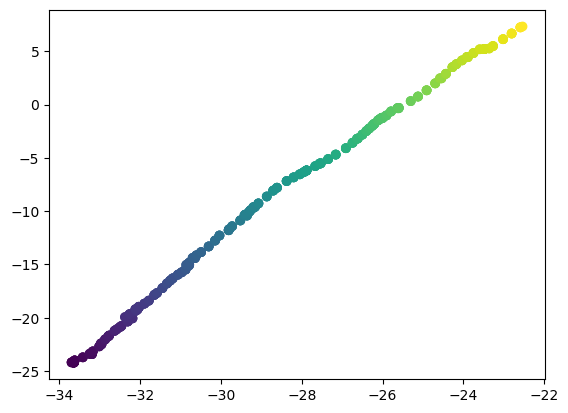

In [9]:
freq = 'ka'

df = data[freq]

x0=np.min(df['x'])
y0=np.min(df['y'])
df['along_track']=np.sqrt((df['x']-x0)**2+(df['y']-y0)**2)


plt.scatter(df['x'],df['y'],c=df['along_track'])

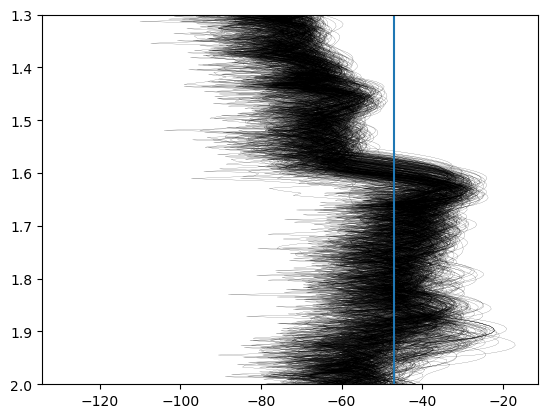

In [10]:
ranges=nearfardict[freq]['range']

for i in range(df.shape[0]):
    d = df.iloc[i]
    power=d['vv']

    plt.plot(10*np.log10(power),
         ranges,
         color='k',lw=0.1)


plt.ylim(2,1.3)
# plt.xlim(-10,0)
if freq =='ka':
    plt.axvline(-47)
elif freq=='ku':
    plt.axvline(-44)
plt.show()

# Analyse peaks

In [11]:
thresh = -44 if freq =='ku' else -47

npeaks = []

multi_peak_inds = {x:{} for x in range(1,5)}

shifts=[]

multipeaks=[]

for i in range(df.shape[0]):
    
    power = df['vv'].iloc[i]
    
    # Identify all peaks more than 10% of max power
    
    ### Identify the indexes of all local maxima
    
    max_inds = argrelextrema(power, np.greater)[0]
    
    ### Catalogue the characteristics of the local maxima
    
    list_of_dicts_for_df = [{'ind':q,'power':power[q],'range':nearfardict[freq]['range'][q]} for q in max_inds]
    
    ### Sort dataframe so modst powerful peaks at top
    
    peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power',ascending=False)
    
    max_power = peaks_df.iloc[0]['power']
    
    # Calculate power of each peak relative to max power
    peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
    
    # Filter out weak peaks with a threshold to remove sidelobes
    peaks_df = peaks_df[10*np.log10(peaks_df['power'])>thresh]
    
    # Sort peaks into ascending range
    peaks_df = peaks_df.sort_values('range',ascending=True)

    shifts.append(peaks_df.iloc[0]['ind'])
    
    # Log npeaks to main dataframe
    npeaks.append(peaks_df.shape[0])

    multipeaks.append(peaks_df)
    
    for pn in range(1,5):
        if peaks_df.shape[0] == pn:
            multi_peak_inds[pn][i] = peaks_df
            
df['shifts']=shifts
df['range_shift']=[ranges[int(x)] for x in df['shifts']]
df['npeaks']=npeaks

df.reset_index(inplace=True)


pickle.dump((ranges,df),open(f'03_morning_{freq}.p','wb'))

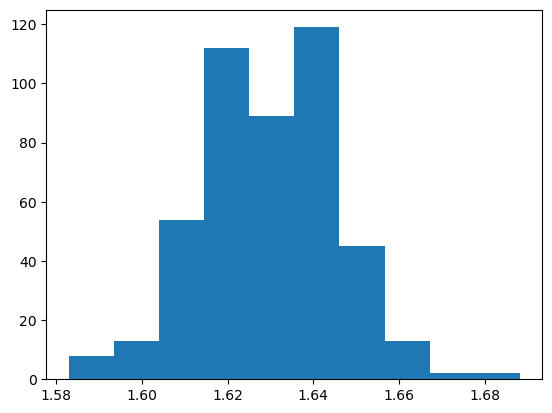

0.003676132769762308 0.016064636610216617


In [12]:
plt.hist(df['range_shift'])
plt.show()
q=df['range_shift']-np.nanmean(df['range_shift'])
print(np.nanmedian(q),np.nanstd(q))

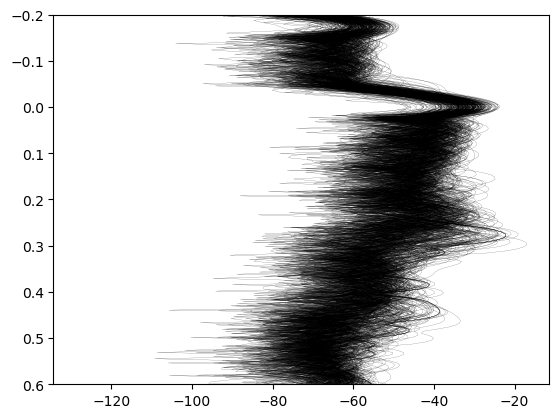

In [13]:

for i in range(df.shape[0]):
    d = df.iloc[i]
    power=d['vv']
    range_shift=d['range_shift']


    plt.plot(10*np.log10(power),
         ranges-range_shift,
         color='k',lw=0.1)

plt.ylim(0.6,-0.2)
# plt.xlim(-10,0)

plt.show()

In [14]:
df.to_csv(f'index_chasing_morning_tmp_{freq}.csv')



ku_pit_indices_raw: 316,441,566,16,94,214,311


ka_pit_indices_raw: 494,722,942,1112,112,328,498
                    16, 93, 164,213, 270,355,411

(120,)
[0.288 0.228 0.252 0.252 0.252 0.348 0.348]
[np.int64(84), np.int64(71), np.int64(76), np.int64(76), np.int64(76), np.int64(97), np.int64(97)]


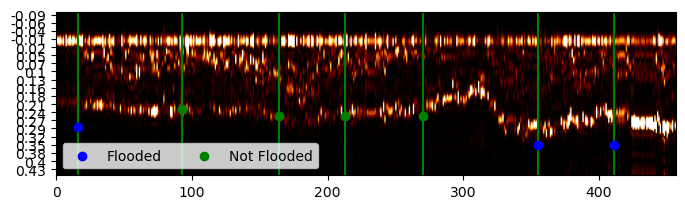

In [25]:
pit_indices={}
pit_indices['ku'] = [8,48,84,118,145,184,213]
pit_indices['ka'] = [16, 93, 164,213, 270,355,411]

n=120
echogram=np.full((df.shape[0],n),np.nan)
echogram=[]
at_valid=[]
for i in range(df.shape[0]):
    d = df.iloc[i]
    power=d['vv']
    along_track=d['along_track']
    shift=int(d['shifts'])
    
    shifted_ranges = ranges-ranges[shift]
    
    power_in_range = power[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
    if i==0:print(power_in_range.shape)
    if power_in_range.shape[0]==n:
        # echogram[i,:]=power_in_range
        echogram.append(power_in_range)
        at_valid.append(along_track)

echogram=np.array(echogram)
at_valid=np.array(at_valid)

plt.figure(figsize=(8,8))

if freq=='ku':
    vmin=0;vmax=0.05
elif freq=='ka':
    vmin=0;vmax=0.001

plt.imshow(echogram.T,vmin=vmin,vmax=vmax,cmap='afmhot')

for i in pit_indices[freq]:
    plt.axvline(i,color='g')

snow_depths = (np.array([24+7,26,28,28,28,36,36])-7)/100
scaled_snow_depths = snow_depths*1.2
print(scaled_snow_depths)

yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]

y_snow_depth_ind=[]
for ssd in scaled_snow_depths:
    #find index of closest shifted range bin to snow depth
    y_snow_depth_ind.append(np.argmin(np.abs(yaxis-ssd)))

floodedx=[pit_indices[freq][0]]+pit_indices[freq][-2:]
floodedy=[y_snow_depth_ind[0]]+y_snow_depth_ind[-2:]
dryx= pit_indices[freq][1:-2]
dryy= y_snow_depth_ind[1:-2]
plt.scatter(floodedx,floodedy,label='Flooded',color='b',zorder=1000)
plt.scatter(dryx,dryy,label='Not Flooded',color='g')
plt.legend(ncols=2,loc='lower left')

print(y_snow_depth_ind)

yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
yticks=np.arange(1,n,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)
plt.show()

In [67]:
pickle_unit=(df,ku_pit_indices,y_snow_depth_ind,ranges)
pickle.dump(pickle_unit,open('echo_morning.p','wb'))

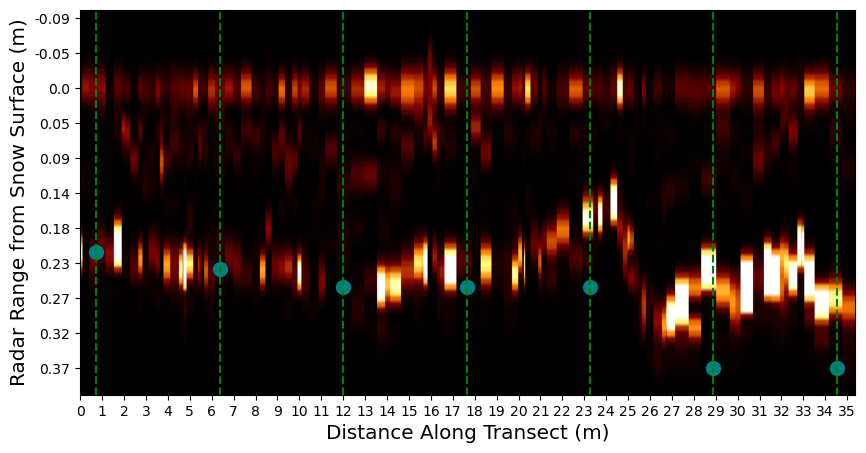

In [113]:
at_linear=np.arange(0,33.6,0.01)

resampled_echogram=np.empty((at_linear.shape[0],n))

for counter,i in enumerate(at_linear):
    distance_to_ats = np.abs(at_valid-i)
    argmin = np.argmin(distance_to_ats)
    resampled_echogram[counter,:]=echogram[argmin]

plt.figure(figsize=(10,5))
plt.imshow(resampled_echogram.T,aspect='auto',
           vmin=0,vmax=0.04,cmap='afmhot')

yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
yticks=np.arange(1,66,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)

xticks=np.arange(0,3360,95)
labels=[int(at_linear[x]) for x in xticks]
plt.xticks(xticks,labels=np.arange(0,36),rotation=0)

pit_inds=np.arange(70,3500,535)
for i in pit_inds:
    plt.axvline(i,color='green',ls='--')

snow_depths = (np.array([24,26,28,28,28,36,36])-7)/100
scaled_snow_depths = snow_depths*1.25

y_snow_depths=[]
for ssd in scaled_snow_depths:
    y_snow_depths.append(np.argmin(np.abs(yaxis-ssd)))

plt.scatter(pit_inds,y_snow_depths,color='teal',s=100)

plt.ylabel('Radar Range from Snow Surface (m)',fontsize='x-large')
plt.xlabel('Distance Along Transect (m)',fontsize='x-large')

plt.show()

In [84]:
data = {}

for freq in ['ku','ka']:

    nrcs_list = []
    for foi in files[freq][2:3]:

        x,y=xy_dict[freq][foi]

        d = Dataset(f'{directory}/{foi}')

        time_offset_s=0
        times = np.array([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(x))+datetime.timedelta(seconds=int(time_offset_s)) for x in d['start_time']])

        mintime=0
        maxtime=100000

        nrcs = pd.DataFrame(kt.get_nrcs(d,freq.lower()))

        x_ = 0; y_ = 0

        if freq=='ku':x=np.nan;y=np.nan
        nrcs['x']=x
        nrcs['y']=y
        nrcs['xtilt']=np.array(d['cross_tilt'])
        nrcs['atilt']=np.array(d['along_tilt'])
        nrcs['time']=np.array(d['start_time'])

        nrcs = nrcs.iloc[mintime:maxtime]

        vv= np.array(d['vv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                           mintime:maxtime]
        
        nrcs['vv'] = [vv[:,i] for i in range(vv.shape[1])]

        nrcs = nrcs[nrcs['corr']<0.99]

        # nrcs_list.append( nrcs.sort_values('along_track').reset_index() )
        nrcs_list.append( nrcs )
        

    data[freq] = pd.concat(nrcs_list)

/tmp/ipykernel_9528/4040675088.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nrcs['xtilt']=np.array(d['cross_tilt'])
/tmp/ipykernel_9528/4040675088.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nrcs['atilt']=np.array(d['along_tilt'])
/tmp/ipykernel_9528/4040675088.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the 

In [85]:
data['ku']['time'].iloc[0]-data['ku']['time'].iloc[-1]

np.float64(-267.748108625412)

In [86]:
data['ka']['time'].iloc[0]-data['ka']['time'].iloc[-1]

np.float64(-268.9399209022522)

In [87]:
freq = 'ku'

thresh = 0.025 if freq=='ku' else 0.01


df = data[freq]

if freq == 'ka':
    x0=np.min(df['x'])
    y0=np.min(df['y'])
    df['along_track']=np.sqrt((df['x']-x0)**2+(df['y']-y0)**2)
# plt.scatter(df['x'],df['y'],c=df['along_track'])
# plt.show()
# plt.scatter(df['time'],df['along_track'])

ranges=nearfardict[freq]['range']

npeaks = []

multi_peak_inds = {x:{} for x in range(1,5)}

shifts=[]

multipeaks=[]

for i in range(df.shape[0]):
    
    power = df['vv'].iloc[i]
    
    # Identify all peaks more than 10% of max power
    
    ### Identify the indexes of all local maxima
    
    max_inds = argrelextrema(power, np.greater)[0]
    
    ### Catalogue the characteristics of the local maxima
    
    list_of_dicts_for_df = [{'ind':q,'power':power[q],'range':nearfardict[freq]['range'][q]} for q in max_inds]
    
    ### Sort dataframe so most powerful peaks at top
    
    peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power',ascending=False)
    
    max_power = peaks_df.iloc[0]['power']
    
    # Calculate power of each peak relative to max power
    peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
    
    # Filter out weak peaks with a threshold to remove sidelobes
    peaks_df = peaks_df[peaks_df['rel_power']>thresh]
    
    # Sort peaks into ascending range
    peaks_df = peaks_df.sort_values('range',ascending=True)

    shifts.append(peaks_df.iloc[0]['ind'])
    
    # Log npeaks to main dataframe
    npeaks.append(peaks_df.shape[0])

    multipeaks.append(peaks_df)
    
    for pn in range(1,5):
        if peaks_df.shape[0] == pn:
            multi_peak_inds[pn][i] = peaks_df
            
df['shifts']=shifts
df['range_shift']=[ranges[int(x)] for x in df['shifts']]
df['npeaks']=npeaks

if freq=='ka':
    n=109
else:
    n=66
# echogram=np.full((df.shape[0],n),np.nan)
echogram=[]
at_valid=[]
srs=[]
for i,mp in zip(range(df.shape[0]),multipeaks):
    d = df.iloc[i]
    power=d['vv']
    if freq=='ka': along_track=d['along_track']
    shift=int(d['shifts'])
    
    # normed_power = np.log10(power/mp.iloc[0]['power'])
    normed_power=power
    shifted_ranges = ranges-ranges[shift]
    # print(shifted_ranges.shape)
    srs.append(shifted_ranges)

    power_in_range = normed_power[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
    # print(power_in_range.shape)
    if power_in_range.shape[0]==n:
        # echogram[i,:]=power_in_range
        echogram.append(power_in_range)
        at_valid.append(along_track)

echogram=np.array(echogram)
at_valid=np.array(at_valid)

snow_depths = (np.array([24,26,28,28,28,36,36]))/100
scaled_snow_depths = (snow_depths-7)*1.25
y_snow_depths=[]
for ssd in scaled_snow_depths:
    y_snow_depths.append(np.argmin(np.abs(yaxis-ssd)))

if freq=='ka':
    vmax=0.001
else:
    vmax=0.08

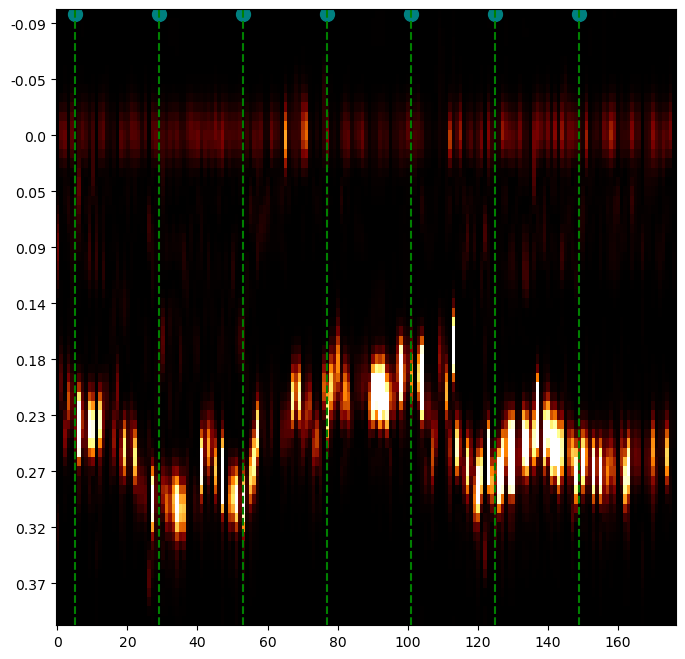

In [88]:
e=echogram.T.copy()

plt.figure(figsize=(8,8))
plt.imshow(echogram.T[:,:],
           # vmin=0,vmax=0.1,
           vmin=0,vmax=vmax,
           cmap='afmhot',
          aspect='auto')

pit_inds=np.arange(5,160,24)
for i in pit_inds:
    plt.axvline(i,color='green',ls='--')

plt.scatter(pit_inds,y_snow_depths,color='teal',s=100)
yaxis = srs[0][(srs[0]>-0.1)&(srs[0]<0.4)]
yticks=np.arange(1,66,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)
plt.show()

In [70]:
scaled_snow_depths

array([0.3  , 0.325, 0.35 , 0.35 , 0.35 , 0.45 , 0.45 ])

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



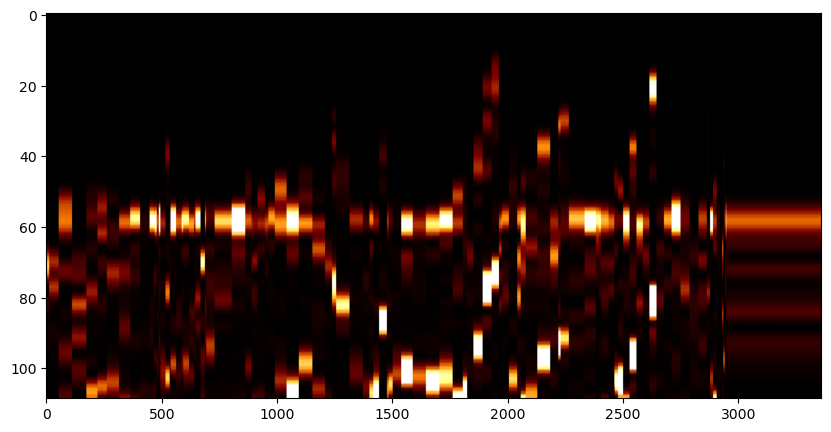

In [49]:
at_linear=np.arange(0,33.6,0.01)

resampled_echogram=np.empty((at_linear.shape[0],n))

for counter,i in enumerate(at_linear):
    distance_to_ats = np.abs(at_valid-i)
    print(distance_to_ats)
    argmin = np.argmin(distance_to_ats)
    resampled_echogram[counter,:]=echogram[argmin]
    # break

plt.figure(figsize=(10,5))
plt.imshow(resampled_echogram.T,aspect='auto',
           vmin=0,vmax=vmax,cmap='afmhot')

36


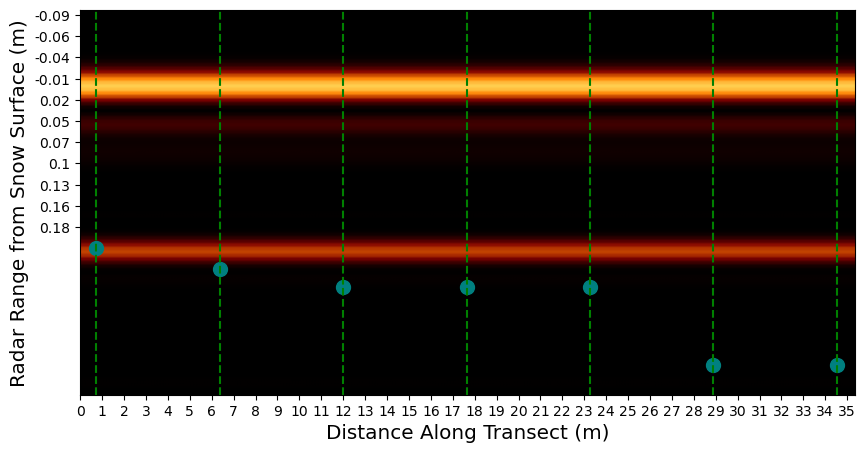

In [118]:
yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
yticks=np.arange(1,66,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)

xticks=np.arange(0,3360,95)
print(len(xticks))
labels=[int(at_linear[x]) for x in xticks]
plt.xticks(xticks,labels=np.arange(0,36),rotation=0)

pit_inds=np.arange(70,3500,535)
for i in pit_inds:
    plt.axvline(i,color='green',ls='--')

snow_depths = (np.array([24,26,28,28,28,36,36])-7)/100
scaled_snow_depths = snow_depths*1.25

y_snow_depths=[]
for ssd in scaled_snow_depths:
    y_snow_depths.append(np.argmin(np.abs(yaxis-ssd)))

plt.scatter(pit_inds,y_snow_depths,color='teal',s=100)

plt.ylabel('Radar Range from Snow Surface (m)',fontsize='x-large')
plt.xlabel('Distance Along Transect (m)',fontsize='x-large')

plt.show()

In [101]:
snow_depths

array([0.24, 0.26, 0.28, 0.28, 0.28, 0.36, 0.36])

(-6.0, 2.0)

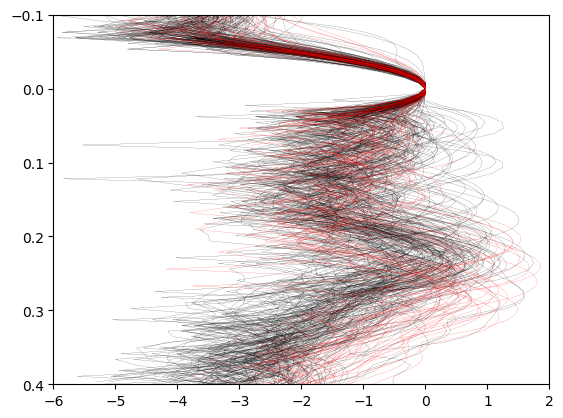

In [24]:

for i,mp in zip(range(df.shape[0]),multipeaks):
    d = df.iloc[i]
    power=d['vv']
    along_track=d['along_track']
    shift=int(d['shifts'])

    if along_track>25:
        color='r'
    else:
        color='k'

    plt.plot(np.log10(power/mp.iloc[0]['power']),
         ranges-ranges[shift],
         color=color,lw=0.1)


plt.ylim(0.4,-0.1)
plt.xlim(-6,2)

In [67]:
powers = []
shifts = []
peak1pow = []

ranges=nearfardict[freq]['range']

for pn in range(1,5):

    for i,peaks_df in multi_peak_inds[pn].items():

        power = df['vv'].iloc[i]
        along_track
        
        powers.append(power)
        shifts.append(peaks_df.iloc[0]['ind'])
        peak1pow.append(peaks_df.iloc[0]['power'])

In [69]:
shifts.shape

AttributeError: 'list' object has no attribute 'shape'

(-6.0, 2.0)

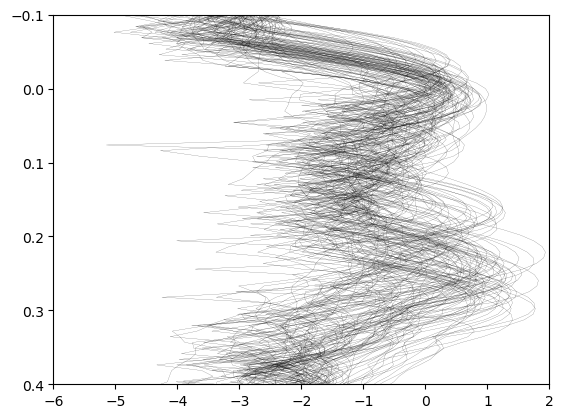

In [55]:
df

,vv,hv,vh,hh,corr,along_track,speed,x,y,xtilt,atilt,npeaks
4,"[4.057605152568576e-06, 2.852908113733917e-06,...",0.003178,0.003338,3.357280,0.882473,31.563689,0.066996,-29.591083,-10.983363,-1.663403,0.100245,2
5,"[3.1744753134852723e-06, 2.434485426660259e-06...",0.007658,0.004180,5.034720,0.763830,31.517150,0.000000,-29.564175,-10.922008,-1.663403,0.100245,3
6,"[2.5796153881223875e-06, 2.163360357553781e-06...",0.018453,0.020519,3.544681,0.524892,31.517150,0.280256,-29.564175,-10.922008,-1.299878,-0.241248,3
7,"[1.0505785682408726e-06, 1.6725894449736637e-0...",0.001208,0.000753,1.246492,0.853317,31.326042,0.000000,-29.455107,-10.663847,-1.299878,-0.241248,2
8,"[4.4446060735964875e-06, 5.0006609044837734e-0...",0.002941,0.002537,2.571522,0.703178,31.326042,0.144935,-29.455107,-10.663847,-1.487148,1.102693,1
...,...,...,...,...,...,...,...,...,...,...,...,...
575,"[7.895308720331757e-06, 6.354383897427528e-06,...",0.002601,0.003820,4.211933,0.757458,24.316729,0.000000,-23.719942,5.354216,-0.506732,-1.067442,3
576,"[7.4513371517923255e-06, 6.802096422834718e-06...",0.014291,0.007051,5.581827,0.973241,24.316729,0.554396,-23.719942,5.354216,0.308446,0.463770,2
577,"[3.972823086404718e-08, 1.3428011948668802e-07...",0.002183,0.001651,2.355536,0.736220,24.257637,0.000000,-23.534987,5.876850,0.308446,0.463770,3
578,"[4.004555409040269e-06, 4.787439539457843e-06,...",0.013825,0.009997,13.031363,0.846632,24.257637,0.602743,-23.534987,5.876850,-0.771114,-2.257160,2


In [ ]:
powers = []
shifts = []
peak1pow = []

ranges=nearfardict[freq]['range']

for i,peaks_df in multi_peak_inds[pn].items():

    power = df['vv'].iloc[i]
    along_track
    
    powers.append(power)
    shifts.append(peaks_df.iloc[0]['ind'])
    peak1pow.append(peaks_df.iloc[0]['power'])
    
    plt.plot(np.log10(power/peaks_df.iloc[0]['power']),
             ranges-peaks_df.iloc[0]['range'],
             color='k',lw=0.1)
    
plt.ylim(0.4,-0.1)
plt.xlim(-6,2)

In [44]:
range_int=np.diff(nearfardict['ku']['range'])[0]
range_int

np.float64(0.00762939453125)

In [45]:
xaxis = np.arange(0,1000,range_int)[:60]-10*range_int

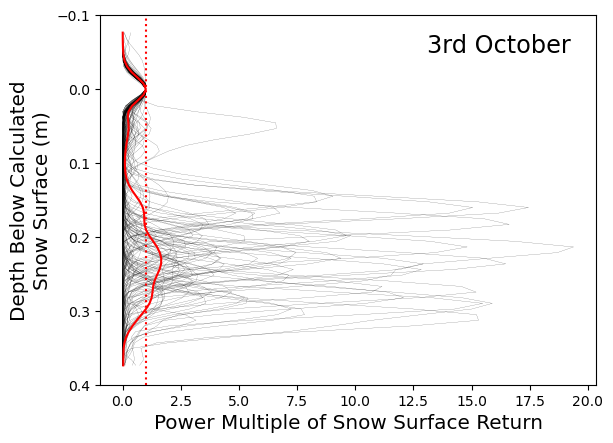

In [46]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(np.array(p_/p1p),xaxis,color='k',lw=0.1)
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(np.array(mean_pow),xaxis,color='r')
    
plt.ylim(0.4,-0.1)

plt.ylabel('Depth Below Calculated\nSnow Surface (m)',fontsize='x-large')

plt.xlabel('Power Multiple of Snow Surface Return',fontsize='x-large')

plt.axvline(1,color='r',ls=':')

plt.annotate('3rd October',xy=(0.95,0.95),ha='right',va='top',fontsize='xx-large',xycoords='axes fraction')

plt.savefig('3oct.png',dpi=500,bbox_inches='tight')

/tmp/ipykernel_1064/2075554975.py:9: RuntimeWarning: divide by zero encountered in log
  plt.plot(xaxis,np.log(p_/p1p),color='k',lw=0.1)


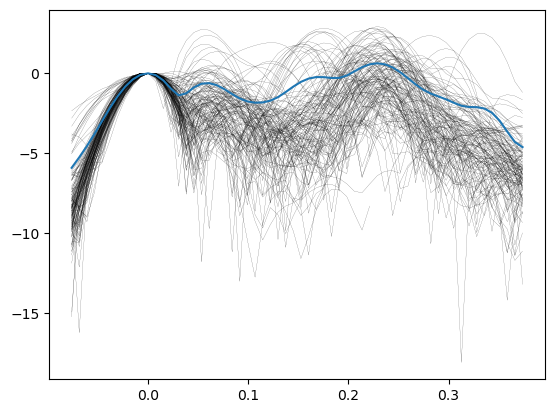

In [93]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(xaxis,np.log(p_/p1p),color='k',lw=0.1)
    
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(xaxis,np.log(mean_pow))
    

In [88]:
np.nanmean(np.array(aligned_powers))

0.0029895847569909166

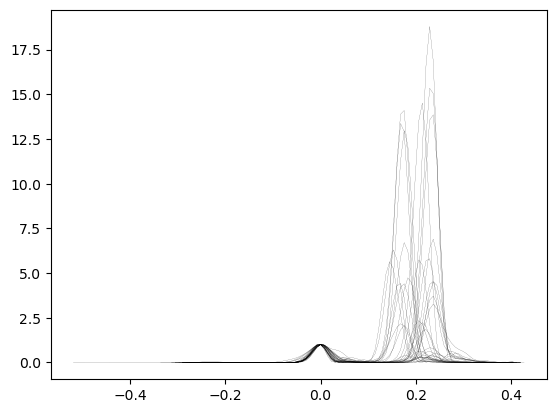

In [24]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

In [ ]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

Text(0, 0.5, 'y distance (m)')

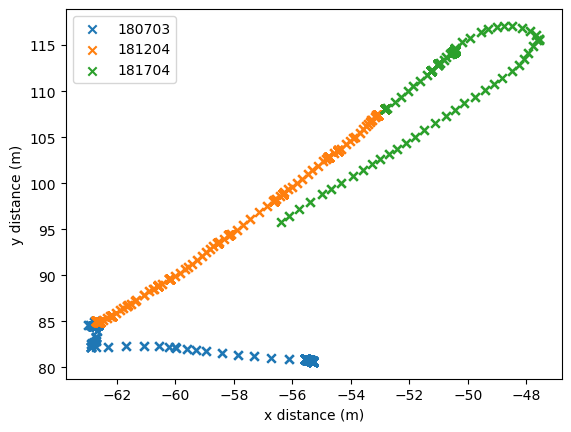

In [5]:
x0,y0 = 0,0

def plot_pos(file,plot=True,x0=0,y0=0):
    
    d = Dataset(f'{directory}/{file}')
    x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')
    y = y[np.abs(x)>10_000] -y0
    x = x[np.abs(x)>10_000] -x0
    if plot:
        plt.scatter(x,y,marker='x',label=file[-9:-3])

    return (x,y)

x,y=plot_pos('kuka_stare_decon_Ka-Scat20231002-135503.nc',plot=False)

x0 = x[0]; y0 = y[0]


# plot_pos('kuka_stare_decon_Ka-Scat20231002-180203.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-180703.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181204.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181704.nc',x0=x0,y0=y0)

plt.legend()
plt.xlabel('x distance (m)')
plt.ylabel('y distance (m)')

# plt.xlim(-20,5)
# plt.ylim(-20,5)

In [6]:
pits = {}

In [7]:
# # Offset between Ka & ku
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

ka = Dataset(f'{directory}/{fa}')['start_time'][0]
ku = Dataset(f'{directory}/{fu}')['start_time'][0]
ka-ku

110.79099631309509

[]

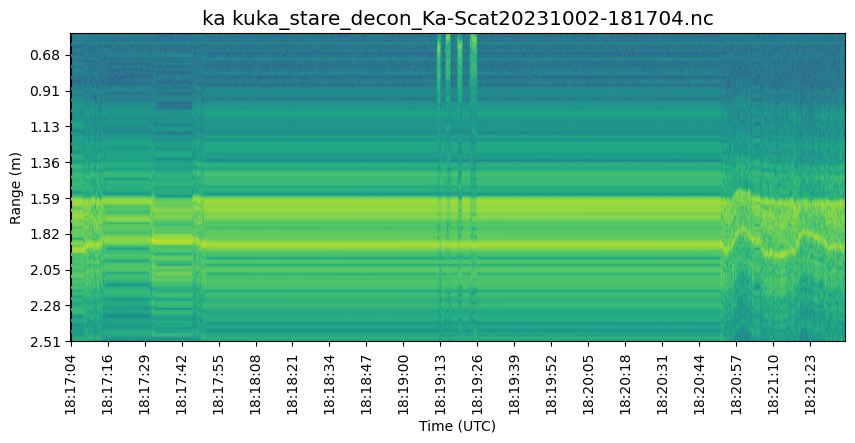

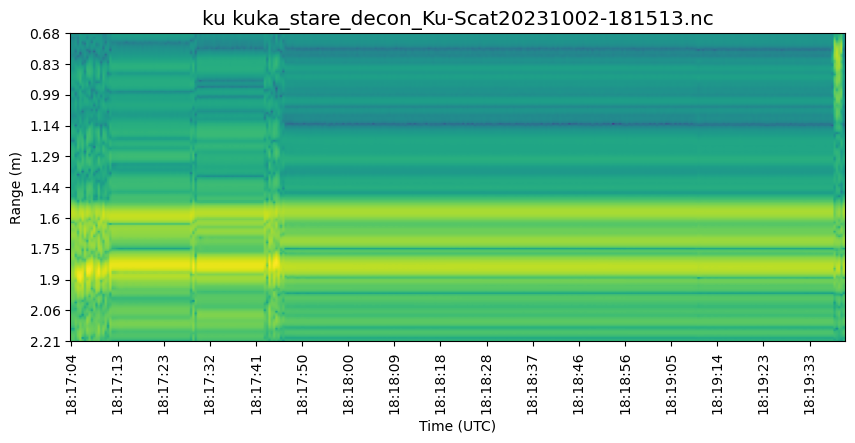

In [8]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(37,55)]
vlines = [datetime.datetime(2023,10,3,10,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,11,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

datetime.timedelta(seconds=21109)

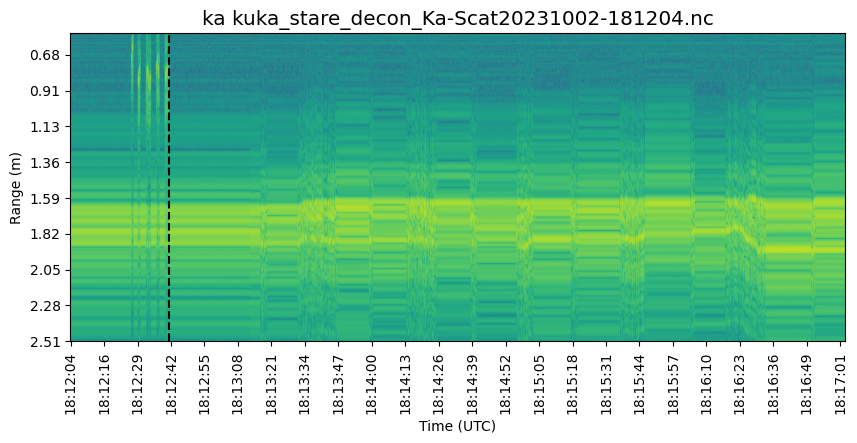

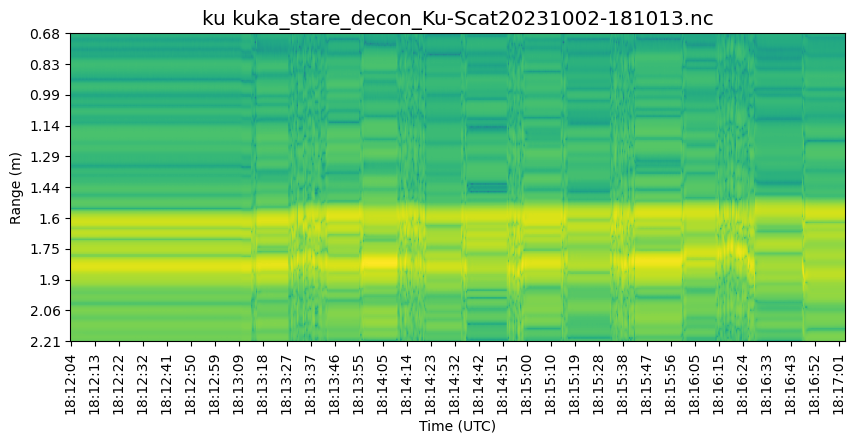

In [9]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(12,42)]
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ka_times]

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

# Voice recording indicates that 18:12:42 kuka time is equal to 12:20:53 on phone

local_delta = datetime.datetime(2023,10,2,18,12,42)-datetime.datetime(2023,10,2,12,20,53)
local_delta

Loc 1
ka 12,21,07
ku 12,21,26

Loc 2
ka 12,21,55
ku 12,22,10

Loc 3
ka 12,22,32
ku 12,22,47

Loc 4
ka 12,23,10
ku 12,23,28

Loc 5
ka 12,23,54
ku 12,24,15

Loc 6
ka 12,24,51
ku 12,25,05

Loc 7
ka 12,25,25
ku 12,25,42

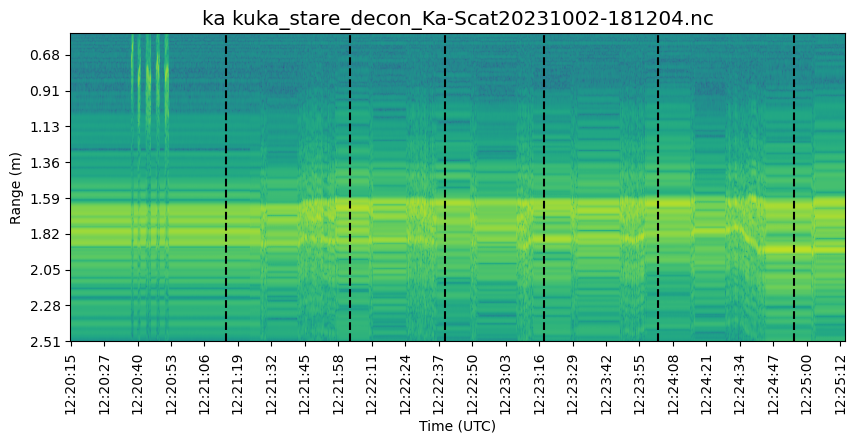

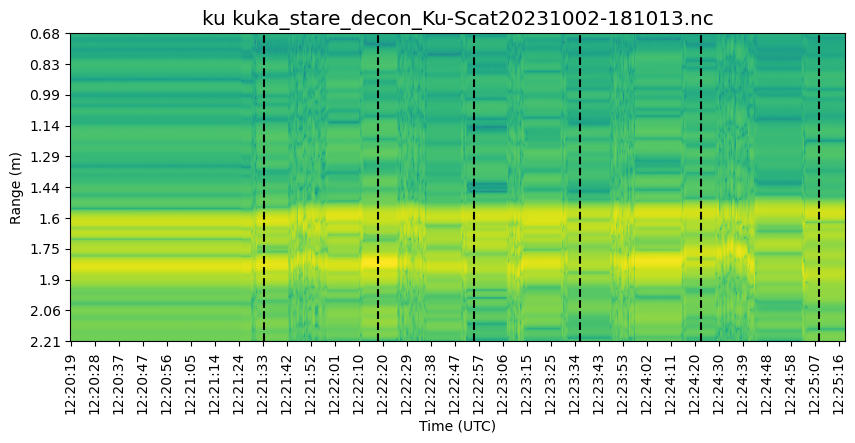

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(21,7),(21,55),(22,32),(23,10),(23,54),(24,47)] #Change last from (24,51) to (24,47)
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]
            # ,(25,25)

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(21,26),(22,10),(22,47),(23,28),(24,15),(25,1)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]
# ,(25,42)

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [1,2,3,4,5,6]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

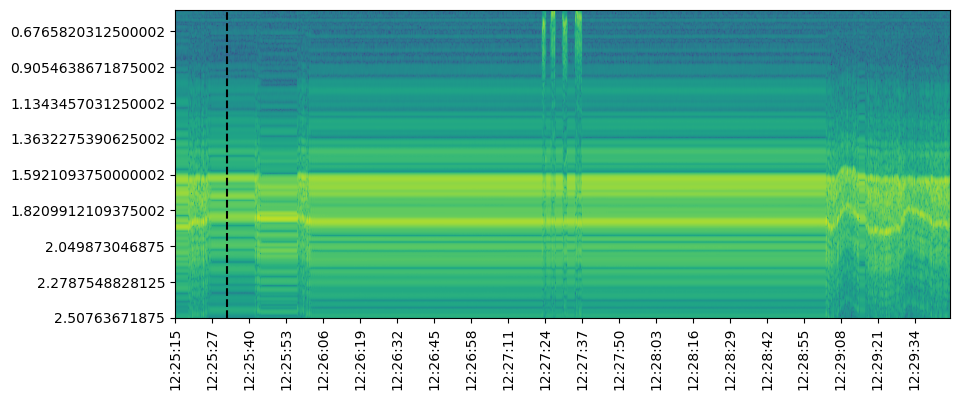

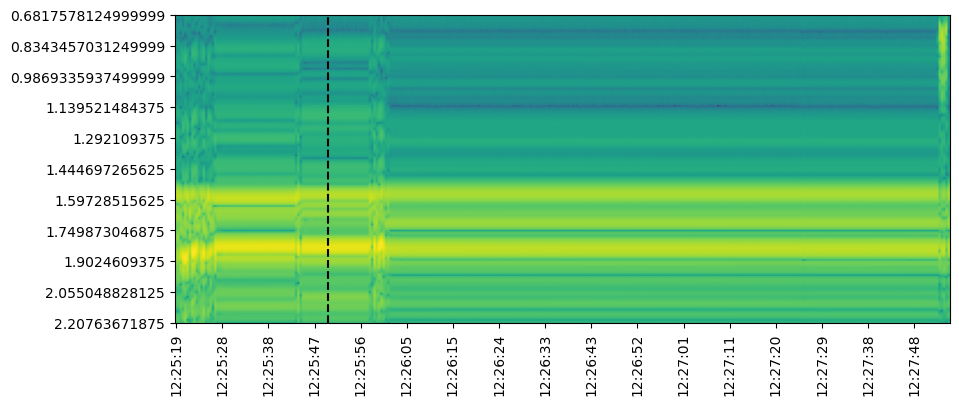

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(25,25)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(25,42)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [7]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

In [ ]:
pols = ['hh','vv',
        # 'hv','vh',
       ]

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [11]:
pols = ['hh','vv','hv','vh']

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [12]:
for freq in ['ka','ku']:

    for h in pits.keys():
    
        data = pits[h]
    
        dic = {pol:data[f'{freq}_{pol}'] for pol in pols}
        
        wvfms = pd.DataFrame(dic)
    
        wvfms.to_csv(f'../data/waveforms/Hangar_2023102_{h}_{freq}.csv')